In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.rcParams['figure.dpi'] = 120
print("\nSetup complete.")

TensorFlow version: 2.21.0
GPU available: False

Setup complete.


Training images shape: (50000, 32, 32, 3)
Test images shape:     (10000, 32, 32, 3)
Image dtype: uint8
Pixel value range: 0 to 255

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


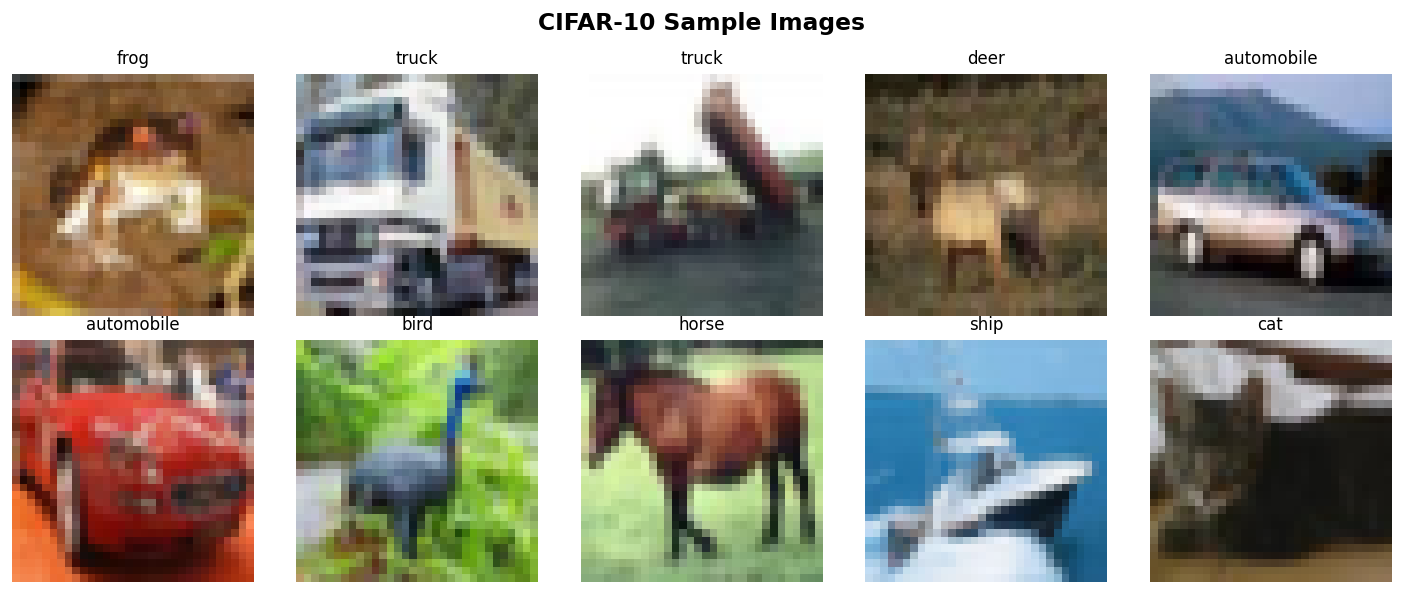

In [3]:
# Load directly from Keras — no download needed
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

print(f"Training images shape: {X_train_raw.shape}")
print(f"Test images shape:     {X_test_raw.shape}")
print(f"Image dtype: {X_train_raw.dtype}")
print(f"Pixel value range: {X_train_raw.min()} to {X_train_raw.max()}")
print(f"\nClasses: {CLASS_NAMES}")

# Flatten label arrays from (50000,1) to (50000,)
y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i])
    ax.set_title(CLASS_NAMES[y_train_raw[i]], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# --- Preprocessing ---
# Normalize pixel values from [0,255] to [0,1]
# WHY: Neural networks train much better with small input values.
# Large inputs cause large gradients which cause unstable training.

IMG_SIZE = 96    # Resize from 32x32 to 96x96 for MobileNetV2
BATCH_SIZE = 64  # Process 64 images at a time during training

def preprocess(image, label):
    """Resize and normalize a single image."""
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

def augment(image, label):
    """Apply augmentation — only during training."""
    # WHY flip: a car facing left and right are both still cars
    image = tf.image.random_flip_left_right(image)
    # WHY crop: teaches model to recognise partial objects
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])
    # WHY brightness: real-world lighting varies
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Build efficient data pipelines using tf.data
# WHY tf.data: loads and preprocesses batches in parallel while GPU trains
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_raw, y_train_raw))
            .shuffle(50000)
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test_raw, y_test_raw))
           .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

print(f"Training batches: {len(train_ds)}")
print(f"Test batches:     {len(test_ds)}")
print(f"Images resized from 32x32 → {IMG_SIZE}x{IMG_SIZE}")

Training batches: 782
Test batches:     157
Images resized from 32x32 → 96x96


In [5]:
# --- Load pretrained MobileNetV2 backbone ---
# include_top=False: removes the ImageNet classification head (1000 classes)
# We only want the feature extraction layers
# weights='imagenet': loads weights trained on 1.2M images
backbone = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# FREEZE the backbone — don't update pretrained weights yet
# WHY: backbone already knows how to extract features.
# Updating it with only 50k images would destroy that knowledge.
backbone.trainable = False

print(f"Backbone: MobileNetV2")
print(f"Backbone parameters: {backbone.count_params():,}")
print(f"Backbone trainable: {backbone.trainable}")

# --- Build the full model ---
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass through pretrained backbone (frozen)
x = backbone(inputs, training=False)

# GlobalAveragePooling: converts feature maps to a single vector
# WHY: reduces spatial dimensions while keeping channel information
# Output: (batch, 1280) vector per image
x = layers.GlobalAveragePooling2D()(x)

# Dropout for regularisation
# WHY: randomly zeros 30% of neurons during training, prevents overfitting
x = layers.Dropout(0.3)(x)

# Dense layer — the actual classification head
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Output layer: 10 neurons = 10 CIFAR classes
# Softmax converts raw scores to probabilities (sum to 1)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nTotal parameters:     {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
model.summary()

Backbone: MobileNetV2
Backbone parameters: 2,257,984
Backbone trainable: False

Total parameters:     2,588,490
Trainable parameters: 330,506


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# Callbacks — functions that run automatically during training

callbacks = [
    # EarlyStopping: stop training if val_accuracy doesn't improve
    # WHY: prevents wasting time training past the optimal point
    # restore_best_weights: rolls back to the best epoch's weights
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # ReduceLROnPlateau: reduce learning rate when stuck
    # WHY: when loss plateaus, smaller steps help fine-tune
    # factor=0.5 means halve the learning rate
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured:")
print("  EarlyStopping — patience=5 epochs")
print("  ReduceLROnPlateau — halves LR when stuck for 3 epochs")

Callbacks configured:
  EarlyStopping — patience=5 epochs
  ReduceLROnPlateau — halves LR when stuck for 3 epochs


In [7]:
print("=" * 55)
print("PHASE 1: Training classification head (backbone frozen)")
print("=" * 55)

history_phase1 = model.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds,
    callbacks=callbacks,
    verbose=1
)

phase1_acc = max(history_phase1.history['val_accuracy'])
print(f"\nPhase 1 best val accuracy: {phase1_acc:.4f} ({phase1_acc*100:.1f}%)")

PHASE 1: Training classification head (backbone frozen)
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 182ms/step - accuracy: 0.6993 - loss: 0.8660 - val_accuracy: 0.7896 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 188ms/step - accuracy: 0.7542 - loss: 0.7041 - val_accuracy: 0.7990 - val_loss: 0.5791 - learning_rate: 0.0010
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 159ms/step - accuracy: 0.7649 - loss: 0.6651 - val_accuracy: 0.7969 - val_loss: 0.5903 - learning_rate: 0.0010
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 122s 156ms/step - accuracy: 0.7774 - loss: 0.6324 - val_accuracy: 0.8092 - val_loss: 0.5538 - learning_rate: 0.0010
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.7853 - loss: 0.6098 - val_accuracy: 0.8080 - val_loss: 0.5593 - learning_rate: 0.0010
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 127s 162ms/step - accuracy: 0.7916 - loss: 0.5926 - val_accuracy: 0.8110 - val_loss: 0.5464 - learning_rate: 0.0010
Epoch 7/

In [8]:
print("=" * 55)
print("PHASE 2: Fine-tuning — unfreezing top backbone layers")
print("=" * 55)

# Unfreeze the top 30 layers of the backbone
# WHY not all layers: lower layers detect basic edges/textures
# (universal, don't need changing). Upper layers detect
# high-level features that benefit from adapting to CIFAR-10.
backbone.trainable = True
fine_tune_at = len(backbone.layers) - 30

for layer in backbone.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters after unfreezing: {trainable_count:,}")

# CRITICAL: use much smaller learning rate for fine-tuning
# WHY: large LR would destroy pretrained weights.
# Small LR = gentle nudges to adapt features to CIFAR-10
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

history_phase2 = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    callbacks=callbacks_ft,
    verbose=1
)

phase2_acc = max(history_phase2.history['val_accuracy'])
print(f"\nPhase 2 best val accuracy: {phase2_acc:.4f} ({phase2_acc*100:.1f}%)")

PHASE 2: Fine-tuning — unfreezing top backbone layers
Trainable parameters after unfreezing: 1,856,906
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 189ms/step - accuracy: 0.7009 - loss: 1.1631 - val_accuracy: 0.8059 - val_loss: 0.6155 - learning_rate: 1.0000e-05
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 180ms/step - accuracy: 0.7642 - loss: 0.8108 - val_accuracy: 0.8188 - val_loss: 0.5550 - learning_rate: 1.0000e-05
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 182ms/step - accuracy: 0.7833 - loss: 0.6915 - val_accuracy: 0.8235 - val_loss: 0.5367 - learning_rate: 1.0000e-05
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - accuracy: 0.8028 - loss: 0.6041 - val_accuracy: 0.8302 - val_loss: 0.5247 - learning_rate: 1.0000e-05
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - accuracy: 0.8168 - loss: 0.5510 - val_accuracy: 0.8347 - val_loss: 0.5076 - learning_rate: 1.0000e-05
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - accuracy: 0.8285 - loss: 0.5020 - val_a

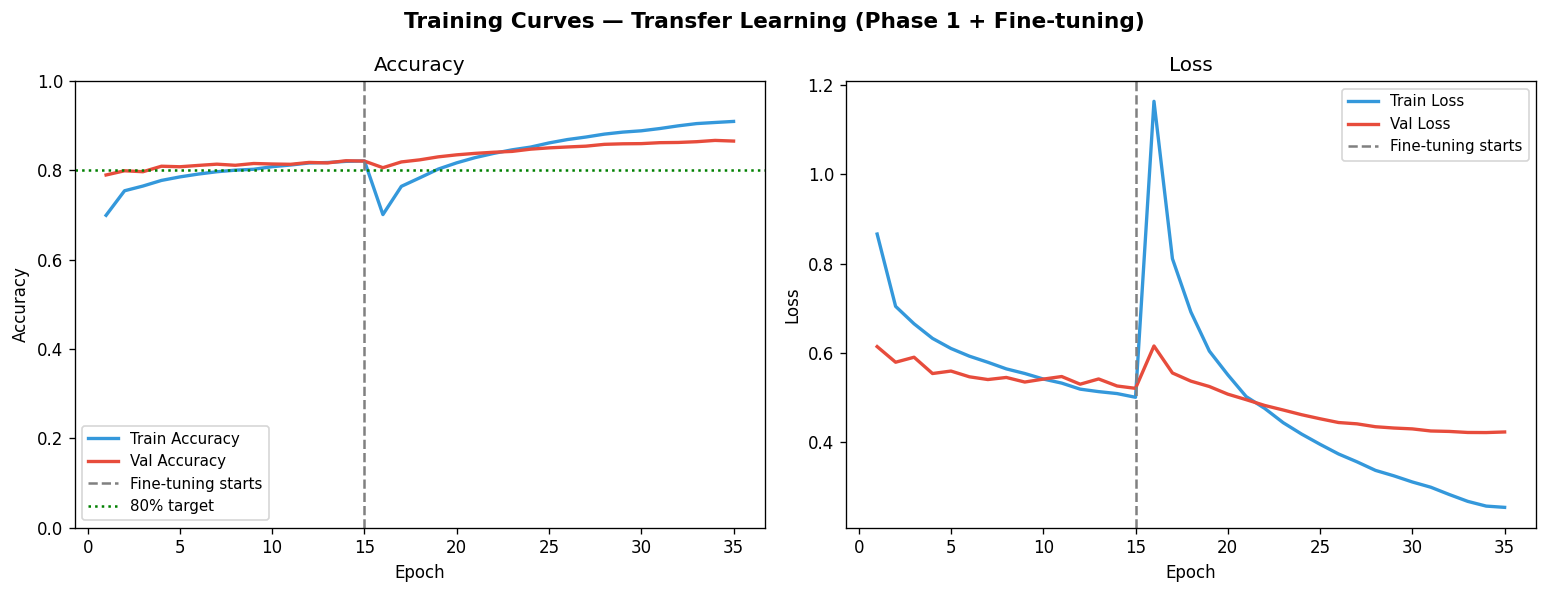

In [9]:
# Combine both phases for plotting
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = combine_histories(history_phase1, history_phase2)
epochs_range = range(1, len(history['accuracy']) + 1)
phase1_end = len(history_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Curves — Transfer Learning (Phase 1 + Fine-tuning)',
             fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(epochs_range, history['accuracy'],
             label='Train Accuracy', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history['val_accuracy'],
             label='Val Accuracy', color='#e74c3c', linewidth=2)
axes[0].axvline(x=phase1_end, color='gray', linestyle='--',
                linewidth=1.5, label='Fine-tuning starts')
axes[0].axhline(y=0.80, color='green', linestyle=':', linewidth=1.5,
                label='80% target')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)

# Loss
axes[1].plot(epochs_range, history['loss'],
             label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(epochs_range, history['val_loss'],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].axvline(x=phase1_end, color='gray', linestyle='--',
                linewidth=1.5, label='Fine-tuning starts')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Target: >80% — {'✅ PASSED' if test_acc > 0.80 else '❌ Not reached yet'}")

# Get all predictions for analysis
y_pred_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"\nClassification Report:")
print(classification_report(y_test_raw, y_pred, target_names=CLASS_NAMES))

FINAL TEST RESULTS
Test Accuracy: 0.8670 (86.7%)
Test Loss:     0.4216
Target: >80% — ✅ PASSED

Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.90      0.89      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.85      0.84      0.85      1000
         cat       0.73      0.76      0.74      1000
        deer       0.82      0.85      0.84      1000
         dog       0.83      0.77      0.80      1000
        frog       0.88      0.90      0.89      1000
       horse       0.91      0.88      0.90      1000
        ship       0.93      0.92      0.92      1000
       truck       0.92      0.92      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



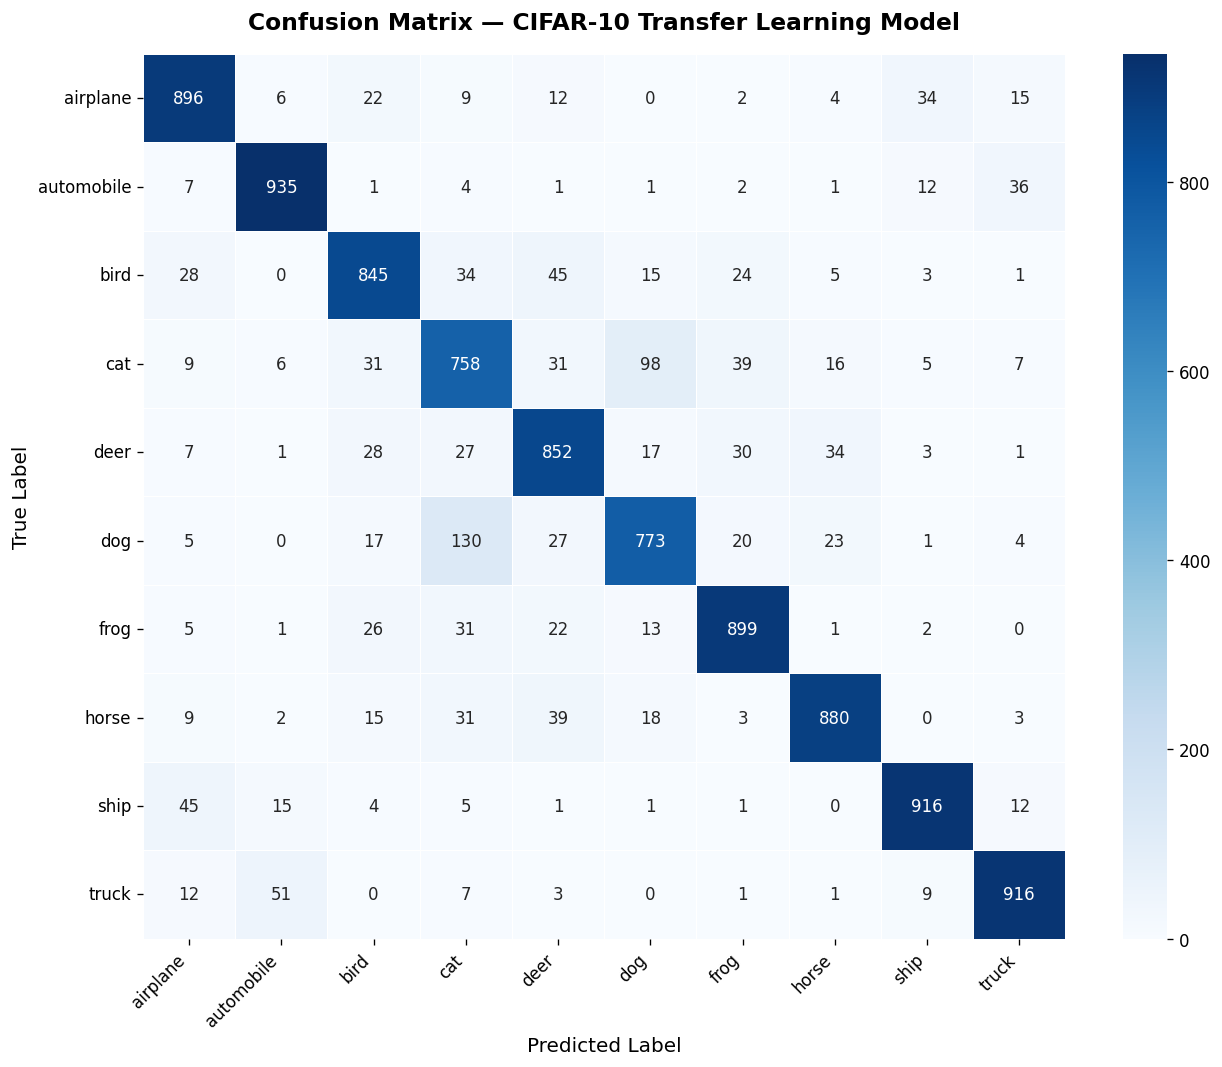


Most confused class pairs:
  True: dog          → Predicted: cat          (130 times)
  True: cat          → Predicted: dog          (98 times)
  True: truck        → Predicted: automobile   (51 times)
  True: bird         → Predicted: deer         (45 times)
  True: ship         → Predicted: airplane     (45 times)


In [12]:
cm = confusion_matrix(y_test_raw, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)

ax.set_title('Confusion Matrix — CIFAR-10 Transfer Learning Model',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
print("\nMost confused class pairs:")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"  True: {CLASS_NAMES[idx[0]]:<12} → Predicted: {CLASS_NAMES[idx[1]]:<12} ({cm_copy[idx]} times)")
    cm_copy[idx] = 0

Total misclassified: 1330 / 10000


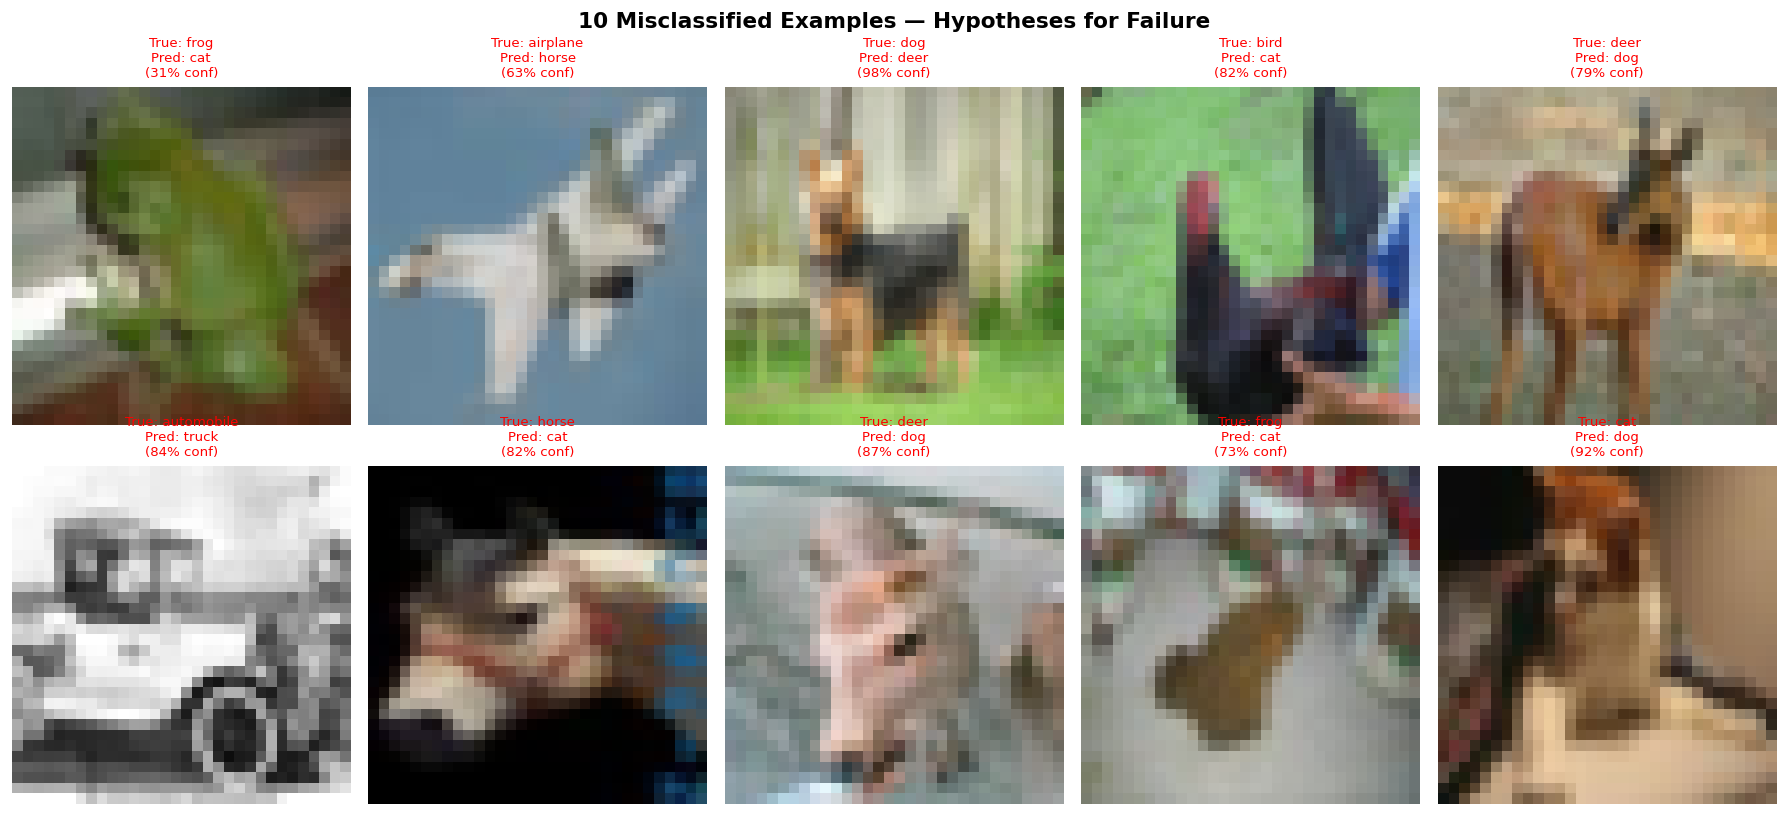

In [13]:
# Find misclassified examples
X_test_display = X_test_raw  # original 32x32 images for display
misclassified_idx = np.where(y_pred != y_test_raw)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test_raw)}")

# Pick first 10
samples = misclassified_idx[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('10 Misclassified Examples — Hypotheses for Failure',
             fontsize=13, fontweight='bold')

for i, (ax, idx) in enumerate(zip(axes.flat, samples)):
    ax.imshow(X_test_display[idx])
    true_label = CLASS_NAMES[y_test_raw[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_proba[idx][y_pred[idx]] * 100
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\n({confidence:.0f}% conf)',
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

## Why Did the Model Fail? — Hypotheses for Misclassified Examples

**cat → dog / dog → cat:**  
Both classes share similar body shapes, fur textures, and typical poses.
The model likely relies on texture and outline — when a cat is photographed 
from an unusual angle or has fur colour similar to common dog breeds, 
the features overlap significantly.

**automobile → truck:**  
CIFAR-10 images are only 32×32 pixels. At this resolution, the distinguishing 
features between a car and a truck (bed, cab height, axle count) are often 
lost — both appear as rectangular boxy shapes with wheels.

**bird → airplane:**  
Both classes can appear as small objects against a blue sky background.
The model may over-index on background colour and silhouette shape 
rather than object-specific features.

**General hypothesis:**  
MobileNetV2 was pretrained on ImageNet where images are 224×224. CIFAR-10's 
32×32 images lose significant detail during upsampling to 96×96. The model 
is working with blurry, artifact-heavy inputs for fine-grained distinctions.
A model trained natively on 32×32 (like a custom CNN) might handle 
texture-based distinctions better at this resolution.

In [ ]:
# Save in .h5 format as required
model.save('cifar10_model.h5')
print("Model saved as cifar10_model.h5")
print(f"File size: {__import__('os').path.getsize('cifar10_model.h5') / 1e6:.1f} MB")

# Verify it loads correctly
loaded_model = keras.models.load_model('cifar10_model.h5')
_, verify_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f"Verification accuracy after reload: {verify_acc*100:.1f}%")
print("✅ Model saved and verified successfully")

Model saved as cifar10_model.h5
File size: 25.6 MB


Verification accuracy after reload: 86.7%
✅ Model saved and verified successfully


: 